<a href="https://colab.research.google.com/github/rc2308/churn-ensemble-engine/blob/main/notebooks/04_modeling_ensemble.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04 — Ensemble Modeling (Stage 2)

**Goal:** Train XGBoost + LightGBM, build a weighted ensemble, evaluate with Gini,
and save all artifacts for the dashboard.

**Uses:** all `src/` modules


In [16]:
import os
os.chdir("/content")
!rm -rf churn-ensemble-engine
!git clone https://github.com/rc2308/churn-ensemble-engine.git
%cd churn-ensemble-engine
!pip install -q -r requirements.txt


Cloning into 'churn-ensemble-engine'...
remote: Enumerating objects: 51, done.
remote: Counting objects: 100% (51/51), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 51 (delta 22), reused 31 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (51/51), 637.28 KiB | 9.24 MiB/s, done.
Resolving deltas: 100% (22/22), done.
/content/churn-ensemble-engine


In [17]:
from google.colab import files
uploaded = files.upload()   # select BankChurners.csv


Saving BankChurners.csv to BankChurners.csv


In [18]:
import pandas as pd
import numpy as np

from src.data_prep import load_data, clean_data, split_data
from src.features import engineer_features, encode_categoricals, scale_for_clustering
from src.clustering import fit_kmeans, assign_clusters

# Pipeline
df = load_data("BankChurners.csv")
df = clean_data(df)
df = engineer_features(df)
df_encoded = encode_categoricals(df)

# Re-create clusters (same features as notebook 03)
clust_feats = [
    "Customer_Age", "Credit_Limit", "Total_Trans_Ct", "Total_Trans_Amt",
    "Avg_Utilization_Ratio", "Months_Inactive_12_mon",
    "Total_Relationship_Count", "Amt_per_Transaction"
]
scaled, scaler = scale_for_clustering(df_encoded, clust_feats)
km = fit_kmeans(scaled, k=4)
df_encoded["Cluster"] = assign_clusters(km, scaled)

print("Final shape:", df_encoded.shape)
df_encoded.head()


Final shape: (10127, 36)


,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,...,Marital_Status_Unknown,Income_Category_$40K - $60K,Income_Category_$60K - $80K,Income_Category_$80K - $120K,Income_Category_Less than $40K,Income_Category_Unknown,Card_Category_Gold,Card_Category_Platinum,Card_Category_Silver,Cluster
0,45,3,39,5,1,3,12691.0,777,11914.0,1.335,...,False,False,True,False,False,False,False,False,False,2
1,49,5,44,6,1,2,8256.0,864,7392.0,1.541,...,False,False,False,False,True,False,False,False,False,2
2,51,3,36,4,1,0,3418.0,0,3418.0,2.594,...,False,False,False,True,False,False,False,False,False,2
3,40,4,34,3,4,1,3313.0,2517,796.0,1.405,...,True,False,False,False,True,False,False,False,False,0
4,40,3,21,5,1,0,4716.0,0,4716.0,2.175,...,False,False,True,False,False,False,False,False,False,2


In [19]:
# Split off a validation set from training data
from sklearn.model_selection import train_test_split

# First: train+val vs test (80/20)
X_temp, X_test, y_temp, y_test = train_test_split(
    df_encoded.drop(columns=["Churn"]), df_encoded["Churn"],
    test_size=0.2, stratify=df_encoded["Churn"], random_state=42
)

# Then: train vs val (from the temp set)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, stratify=y_temp, random_state=42
)

# Train on train, tune w on VALIDATION, evaluate on TEST



In [25]:
from src.models import train_xgb, train_lgbm

xgb = train_xgb(X_train, y_train)
lgbm = train_lgbm(X_train, y_train)

# Get predicted probabilities on test set
p_xgb  = xgb.predict_proba(X_test)[:, 1]
p_lgbm = lgbm.predict_proba(X_test)[:, 1]

print("Models trained ")


Models trained 


In [21]:
from src.models import optimize_ensemble_weight, ensemble_predict

# Find best weight (using test set here for simplicity)
best_w = optimize_ensemble_weight(p_xgb, p_lgbm, y_test)
print(f"Best ensemble weight w = {best_w:.2f}")
print(f"  ({best_w:.0%} XGBoost, {1-best_w:.0%} LightGBM)")

# Ensemble predictions
p_ens = ensemble_predict(p_xgb, p_lgbm, best_w)


Best ensemble weight w = 0.80
  (80% XGBoost, 20% LightGBM)


In [22]:
from src.evaluate import compute_metrics, comparison_table

results = {
    "XGBoost":  compute_metrics(y_test, p_xgb),
    "LightGBM": compute_metrics(y_test, p_lgbm),
    "Ensemble": compute_metrics(y_test, p_ens),
}

table = comparison_table(results)
print("Model Comparison:")
table


Model Comparison:


,gini,auc,pr_auc,recall,f1
XGBoost,0.9845,0.9923,0.9676,0.9108,0.8970
LightGBM,0.9835,0.9918,0.9644,0.9108,0.8849
Ensemble,0.9847,0.9923,0.9678,0.9108,0.8943


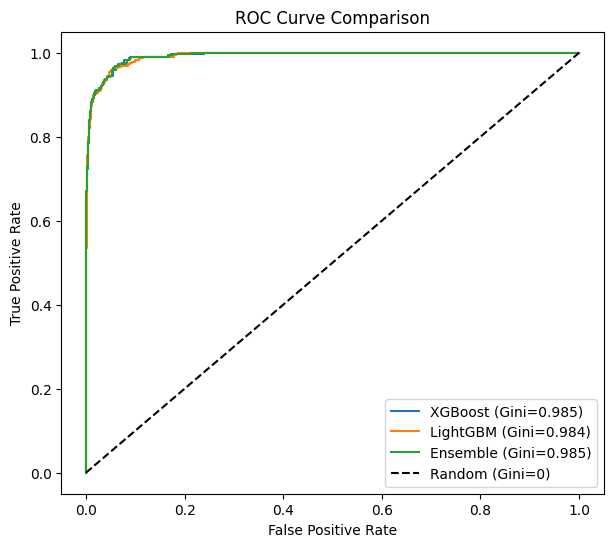

In [23]:
from src.evaluate import plot_roc_curves

plot_roc_curves(
    y_test,
    {"XGBoost": p_xgb, "LightGBM": p_lgbm, "Ensemble": p_ens},
    save_path="reports/figures/roc_comparison.png"
)


In [24]:
# Check what's driving the predictions
import pandas as pd

importances = pd.Series(xgb.feature_importances_, index=X_train.columns)
print("Top 10 most important features:")
print(importances.sort_values(ascending=False).head(10))


Top 10 most important features:
Total_Trans_Ct              0.217246
Total_Revolving_Bal         0.108381
Total_Relationship_Count    0.070825
Amt_per_Transaction         0.066960
Total_Ct_Chng_Q4_Q1         0.054968
Total_Trans_Amt             0.053501
Months_Inactive_12_mon      0.040454
Cluster                     0.035522
Gender_M                    0.030603
Total_Amt_Chng_Q4_Q1        0.029195
dtype: float32


In [32]:
# PRODUCTION: retrain on ALL data (no split) for deployment
X_full = df_encoded.drop(columns=["Churn"])
y_full = df_encoded["Churn"]

xgb_final  = train_xgb(X_full, y_full)
lgbm_final = train_lgbm(X_full, y_full)

print("Production models retrained on full data ")


Production models retrained on full data 


In [34]:
import joblib, json, os

os.makedirs("artifacts", exist_ok=True)

# Save production models + clustering + scaler
joblib.dump(xgb_final,  "artifacts/xgb_model.joblib")
joblib.dump(lgbm_final, "artifacts/lgbm_model.joblib")
joblib.dump(km,         "artifacts/kmeans.joblib")
joblib.dump(scaler,     "artifacts/scaler.joblib")

# Save the ensemble weight (from Cell 7)
json.dump({"w": float(best_w)}, open("artifacts/ensemble_weight.json", "w"))

# Save feature columns (order matters!)
feature_columns = X_full.columns.tolist()
json.dump(feature_columns, open("artifacts/feature_columns.json", "w"))

# Save clustering features
json.dump(clust_feats, open("artifacts/clust_feats.json", "w"))

# Save persona map
persona_map = {
    "0": "Loyal Revolvers",
    "1": "High-Value Spenders",
    "2": "At-Risk Average Users",
    "3": "Dormant High-Limit"
}
json.dump(persona_map, open("artifacts/persona_map.json", "w"))

print("All artifacts saved ")
print(os.listdir("artifacts"))


All artifacts saved 
['ensemble_weight.json', 'clust_feats.json', 'lgbm_model.joblib', 'scaler.joblib', 'feature_columns.json', '.gitkeep', 'xgb_model.joblib', 'persona_map.json', 'kmeans.joblib']


In [35]:
# Zip and download artifacts to your laptop
!zip -r artifacts.zip artifacts/
from google.colab import files
files.download("artifacts.zip")


  adding: artifacts/ (stored 0%)
  adding: artifacts/ensemble_weight.json (stored 0%)
  adding: artifacts/clust_feats.json (deflated 27%)
  adding: artifacts/lgbm_model.joblib (deflated 62%)
  adding: artifacts/scaler.joblib (deflated 33%)
  adding: artifacts/feature_columns.json (deflated 59%)
  adding: artifacts/.gitkeep (stored 0%)
  adding: artifacts/xgb_model.joblib (deflated 76%)
  adding: artifacts/persona_map.json (deflated 17%)
  adding: artifacts/kmeans.joblib (deflated 90%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>